In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Set plot style
sns.set(style="whitegrid")


In [17]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
rb_df = pd.read_csv(DATA_DIR / "Game_Logs_Runningback.csv")
rb_df.head(10)

,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Yards Per Carry,Longest Rushing Run,Rushing TDs,Receptions,Receiving Yards,Yards Per Reception,Longest Reception,Receiving TDs,Fumbles,Fumbles Lost
0,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,7,10/20,Away,ATL,L,...,--,--,--,--,--,--,--,--,--,--
1,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,8,10/27,Home,NYG,L,...,--,--,--,--,--,--,--,--,--,--
2,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,9,11/03,Away,RAM,L,...,--,--,--,3,27,9.0,10,0,--,--
3,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,10,11/10,Home,SEA,L,...,--,--,--,--,--,--,--,--,--,--
4,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,11,11/17,Away,GB,L,...,1.0,1,0,--,--,--,--,--,--,--
5,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,12,11/24,Away,MIN,W,...,--,--,--,--,--,--,--,--,--,--
6,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,13,12/01,Home,RAM,W,...,--,--,--,--,--,--,--,--,--,--
7,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,14,12/08,Away,STL,L,...,--,--,--,--,--,--,--,--,--,--
8,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,15,12/15,Home,SF,L,...,--,--,--,--,--,--,--,--,--,--
9,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,16,12/22,Home,ATL,L,...,3.0,3,0,2,16,8.0,11,0,--,--


In [18]:
rb_df["Rushing Attempts"] = pd.to_numeric(rb_df["Rushing Attempts"], errors="coerce")
rb_df["Rushing Yards"] = pd.to_numeric(rb_df["Rushing Yards"], errors="coerce")

# Calculate Yards Per Carry if not already present
if "Yards Per Carry" not in rb_df.columns:
    rb_df["Yards Per Carry"] = rb_df["Rushing Yards"] / rb_df["Rushing Attempts"]

# Filter out rows with missing data
rb_clean = rb_df.dropna(subset=["Rushing Attempts", "Yards Per Carry"])
rb_clean.head()


,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Yards Per Carry,Longest Rushing Run,Rushing TDs,Receptions,Receiving Yards,Yards Per Reception,Longest Reception,Receiving TDs,Fumbles,Fumbles Lost
4,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,11,11/17,Away,GB,L,...,1.0,1,0,--,--,--,--,--,--,--
9,bobbyfowler/2514295,"Fowler, Bobby",NaN,1985,Regular Season,16,12/22,Home,ATL,L,...,3.0,3,0,2,16,8.0,11,0,--,--
31,quinnjohnson/79593,"Johnson, Quinn",NaN,2012,Regular Season,10,11/11,Away,MIA,W,...,3.0,3,0,0,0,--,--,0,--,--
35,quinnjohnson/79593,"Johnson, Quinn",NaN,2012,Regular Season,15,12/17,Home,NYJ,W,...,1.0,1,0,1,2,2.0,2,0,--,--
36,quinnjohnson/79593,"Johnson, Quinn",NaN,2012,Regular Season,16,12/23,Away,GB,L,...,0.0,0,0,--,--,--,--,--,--,--


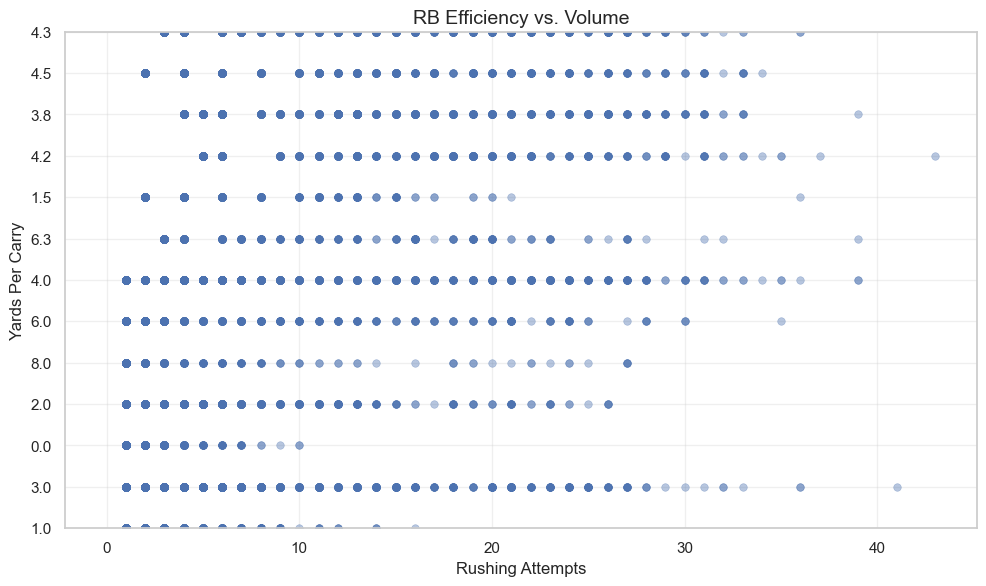

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rb_clean,
    x="Rushing Attempts",
    y="Yards Per Carry",
    alpha=0.4,
    s=30,  # smaller marker size
    edgecolor=None
)

plt.title("RB Efficiency vs. Volume", fontsize=14)
plt.xlabel("Rushing Attempts", fontsize=12)
plt.ylabel("Yards Per Carry", fontsize=12)
plt.ylim(0, 12)  # clamp extreme outliers
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=1.0)
plt.show()


## 🧮 Feature Selection for RB Analysis

| Feature Column              | Purpose                              |
|-----------------------------|--------------------------------------|
| **Rushing Attempts**        | Volume                               |
| **Yards Per Carry**         | Efficiency                           |
| **Rushing Yards**           | 🎯 Prediction Target                 |



## Linear Regression Model <br>
1. Rushing Attempts (volume) <br>
2. Yards Per Carry (efficiency) <br>
### Goal: "Can we estimate how many rushing yards a player will gain based on how many carries they get and how efficient they are?"

In [20]:
# Use only rows where Rushing Yards, Attempts, and YPC are valid
rb_model_df = rb_clean.dropna(subset=["Rushing Yards", "Rushing Attempts", "Yards Per Carry"])
# Convert all relevant columns safely to numbers
rb_model_df = rb_clean.copy()

cols_to_fix = ["Rushing Attempts", "Yards Per Carry", "Rushing Yards"]
for col in cols_to_fix:
    rb_model_df[col] = pd.to_numeric(rb_model_df[col], errors="coerce")

# Drop rows with any NaN values in those columns
rb_model_df = rb_model_df.dropna(subset=cols_to_fix)

# Define feature matrix X and target y
X = rb_model_df[["Rushing Attempts", "Yards Per Carry"]]
y = rb_model_df["Rushing Yards"]


Split Data into Train and Test

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)  
y_pred = model.predict(X_test)

In [23]:
# Print evaluation metrics
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R² Score: 0.854
Mean Squared Error: 201.02
Model Coefficients: [4.19958436 3.8527411 ]
Intercept: -16.0777145931214


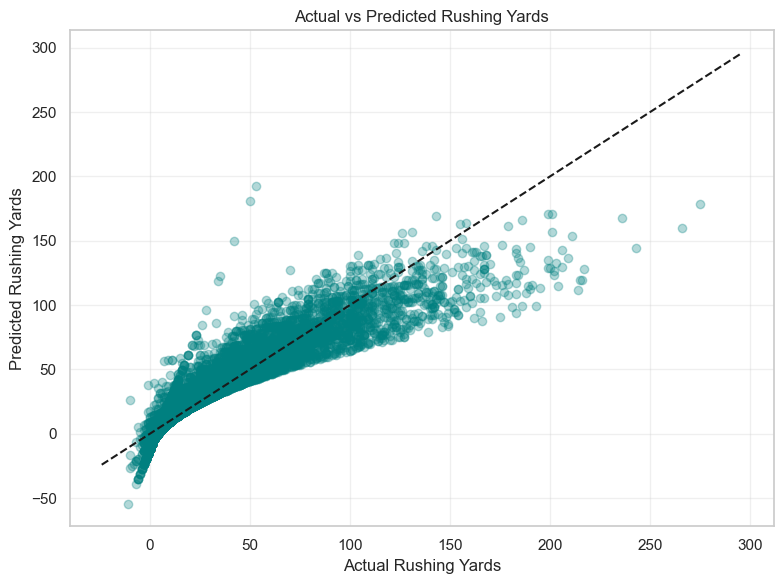

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color="teal")
plt.xlabel("Actual Rushing Yards")
plt.ylabel("Predicted Rushing Yards")
plt.title("Actual vs Predicted Rushing Yards")
plt.grid(True, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')  # reference line
plt.tight_layout()
plt.show()


## ✅ Linear Regression Results Summary – RB Rushing Yards

### 🎯 Model Goal:
Predict a running back’s **total rushing yards in a game** based on:
- **Rushing Attempts** (volume)
- **Yards Per Carry** (efficiency)

---

### 📈 Model Results:
- **R² Score:** `0.854`  
  ➤ The model explains ~85.4% of the variance in rushing yards — a strong fit.

- **Mean Squared Error (MSE):** `201.02`  
  ➤ On average, predictions are off by about **√201 ≈ 14.1 yards**.

- **Model Equation:**
\[
\Predicted Yards=4.20⋅Attempts+3.85⋅YPC−16.08
\]

- **Coefficients:**
  | Feature             | Coefficient | Interpretation |
  |---------------------|-------------|----------------|
  | **Rushing Attempts** | `+4.20`     | Each extra carry adds ~4.2 yards (holding YPC constant) |
  | **Yards Per Carry**  | `+3.85`     | A 1-point YPC boost adds ~3.85 yards (holding attempts constant) |
  | **Intercept**        | `-16.08`    | Base offset when both inputs are zero (not meaningful here) |

---

### 📊 Plot Interpretation:
- Scatterplot shows **predicted vs. actual** rushing yards.
- Most points are tightly clustered near the ideal line → model fits well.
- A bit more spread at high yardage levels indicates **greater variability** in big games.

---

## 📚 What Do the Variables in Linear Regression Mean?

- **Coefficient (β)**: Tells you how much the target variable (e.g. rushing yards) changes with a 1-unit increase in the input feature.
  - If `β = 4.2` for Rushing Attempts → every extra carry adds ~4.2 yards.
- **Intercept (β₀)**: The predicted value when all features are 0. Often not meaningful, but required mathematically.
- **R² Score**: Measures how much of the variance in the target is explained by the model.
  - `R² = 0.85` means 85% of the variation in rushing yards is explained by your input features.
- **MSE (Mean Squared Error)**: Average of the squared difference between predicted and actual values.
  - Lower MSE = better fit.

---

## ✅ Conclusion:
- This linear model is **accurate and interpretable**.
- **Rushing attempts** are the dominant predictor of total yardage.
- **Yards per carry** adds useful nuance, but volume matters more.


## 📈 RB Rushing Yards Predictor (Using Linear Regression)

Use this function to estimate rushing yards for a given number of carries and yards per carry (YPC).

Example:
```python
predict_rushing_yards(attempts=20, ypc=4.2)


In [26]:
# Define a reusable predictor function
def predict_rushing_yards(attempts, ypc):
    """
    Predict rushing yards using the trained linear regression model.
    
    Parameters:
        attempts (float): Number of rushing attempts
        ypc (float): Yards per carry
        
    Returns:
        float: Predicted rushing yards (rounded)
    """
    input_data = [[attempts, ypc]]
    prediction = model.predict(input_data)[0]
    prediction_rounded = round(prediction, 2)

    # Print out details for user context
    print("📊 Prediction Details")
    print(f"Rushing Attempts: {attempts}")
    print(f"Yards Per Carry: {ypc}")
    print(f"🔮 Predicted Rushing Yards: {prediction_rounded}")
    
    return prediction_rounded

# Example usage
predict_rushing_yards(attempts=20, ypc=4.5)

📊 Prediction Details
Rushing Attempts: 20
Yards Per Carry: 4.5
🔮 Predicted Rushing Yards: 85.25


/usr/local/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


85.25